In [1]:
%%capture
!uv pip install numpy pandas scanpy

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc

In [3]:
import warnings
import gc
warnings.simplefilter(action='ignore', category=Warning)

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80)

In [4]:
# Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
data_path = os.path.join("/content/drive/MyDrive/data", "raw")

# Get the list of .h5 files
h5_files = [file for file in os.listdir(data_path) if file.endswith(".h5")]

# Initialize list to store AnnData objects
adatas_list = []

# Load each sample
for file_name in h5_files:
    file_path = os.path.join(data_path, file_name)
    adata = sc.read_10x_h5(file_path)
    adata.var_names_make_unique()
    adatas_list.append(adata)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/data/raw'

In [7]:
os.listdir("data/raw")

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw'

In [8]:
import os
import glob
import scanpy as sc

# Define directory where your raw .h5 files are stored
raw_dir = "/content/drive/MyDrive/drosophila_scRNAseq_project/data/raw"

# Find all .h5 files in that directory
h5_files = sorted(glob.glob(os.path.join(raw_dir, "*.h5")))

# Dictionary to hold individual loaded AnnData objects
adatas = {}

print(f"Found {len(h5_files)} .h5 files to load.")

for file_path in h5_files:
    # Get sample name from the filename (e.g., 'ncov_pbmc_1')
    sample_name = os.path.basename(file_path).replace(".h5", "")
    print(f"Loading {sample_name}...")

    # Load 10x H5 file
    adata = sc.read_10x_h5(file_path)

    # Make gene names unique to avoid downstream errors
    adata.var_names_make_unique()

    # Append sample name to cell barcodes to avoid overlap between samples
    adata.obs_names = [f"{sample_name}_{barcode}" for barcode in adata.obs_names]

    # Track origin sample in metadata
    adata.obs['sample'] = sample_name

    adatas[sample_name] = adata

# Combine all individual samples into one master AnnData object
adata = sc.concat(adatas, merge="same")
adata.obs_names_make_unique()

print("\n--- Integrated Master AnnData ---")
print(adata)

Found 0 .h5 files to load.


ValueError: No objects to concatenate

In [9]:
working_dir = "/content/drive/MyDrive/drosophila_scRNAseq_project/data /raw"
os.chdir(working_dir)

In [10]:
# project tree
for root, dirs, files in os.walk("."):
    level = root.count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    for file in files:
        print("  " * (level + 1) + file)

./
  ncov_pbmc_15.h5
  ncov_pbmc_16.h5
  normal_pbmc_14.h5
  normal_pbmc_5.h5
  ncov_pbmc_1.h5
  normal_pbmc_19.h5
  ncov_pbmc_17.h5
  normal_pbmc_13.h5


In [12]:
import os
import glob
import scanpy as sc

# Define directory where your raw .h5 files are stored
raw_dir = "/content/drive/MyDrive/drosophila_scRNAseq_project/data /raw"

# Find all .h5 files in that directory
h5_files = sorted(glob.glob(os.path.join(raw_dir, "*.h5")))

# Dictionary to hold individual loaded AnnData objects
adatas = {}

print(f"Found {len(h5_files)} .h5 files to load.")

for file_path in h5_files:
    # Get sample name from the filename (e.g., 'ncov_pbmc_1')
    sample_name = os.path.basename(file_path).replace(".h5", "")
    print(f"Loading {sample_name}...")

    # Load 10x H5 file
    adata = sc.read_10x_h5(file_path)

    # Make gene names unique to avoid downstream errors
    adata.var_names_make_unique()

    # Append sample name to cell barcodes to avoid overlap between samples
    adata.obs_names = [f"{sample_name}_{barcode}" for barcode in adata.obs_names]

    # Track origin sample in metadata
    adata.obs['sample'] = sample_name

    adatas[sample_name] = adata

# Combine all individual samples into one master AnnData object
adata = sc.concat(adatas, merge="same")
adata.obs_names_make_unique()

print("\n--- Integrated Master AnnData ---")
print(adata)

Found 8 .h5 files to load.
Loading ncov_pbmc_1...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_1.h5
 (0:00:01)
Loading ncov_pbmc_15...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_15.h5
 (0:00:01)
Loading ncov_pbmc_16...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_16.h5
 (0:00:01)
Loading ncov_pbmc_17...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_17.h5
 (0:00:01)
Loading normal_pbmc_13...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_13.h5
 (0:00:01)
Loading normal_pbmc_14...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_14.h5
 (0:00:01)
Loading normal_pbmc_19...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_19.h5
 (0:00:01)
Loading normal_pbmc_5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_5.h5
 (0:00:00)



In [14]:
data_path = working_dir

# Get the list of .h5 files
h5_files = [file for file in os.listdir(data_path) if file.endswith(".h5")]

# Initialize list to store AnnData objects
adatas_list = []

# Load each sample
for file_name in h5_files:
    file_path = os.path.join(data_path, file_name)
    adata = sc.read_10x_h5(file_path)
    adata.var_names_make_unique()
    adatas_list.append(adata)

reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_15.h5
 (0:00:00)
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_16.h5
 (0:00:00)
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_14.h5
 (0:00:00)
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_5.h5
 (0:00:00)
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_1.h5
 (0:00:00)
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_19.h5
 (0:00:00)
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_17.h5
 (0:00:00)
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_13.h5
 (0:00:00)


In [15]:
adatas_list

[AnnData object with n_obs × n_vars = 1500 × 33538
     var: 'gene_ids', 'feature_types', 'genome',
 AnnData object with n_obs × n_vars = 1500 × 33538
     var: 'gene_ids', 'feature_types', 'genome',
 AnnData object with n_obs × n_vars = 1500 × 33538
     var: 'gene_ids', 'feature_types', 'genome',
 AnnData object with n_obs × n_vars = 1500 × 33538
     var: 'gene_ids', 'feature_types', 'genome',
 AnnData object with n_obs × n_vars = 1500 × 33538
     var: 'gene_ids', 'feature_types', 'genome',
 AnnData object with n_obs × n_vars = 1500 × 33538
     var: 'gene_ids', 'feature_types', 'genome',
 AnnData object with n_obs × n_vars = 1500 × 33538
     var: 'gene_ids', 'feature_types', 'genome',
 AnnData object with n_obs × n_vars = 1500 × 33538
     var: 'gene_ids', 'feature_types', 'genome']

In [16]:
adatas_list[0].obs

""
CTGGCAGAGCGCGTTC-15
CATGGTAGTTGTAAAG-15
TTTCAGTTCTATCGCC-15
CTATAGGTCCACCTCA-15
GTGGCGTCAACTTGGT-15
...
ATTCCTAGTTGCGTAT-15
GAATCACGTACGATTC-15
GTGTTAGAGGATTCAA-15
GTAATCGAGTGGTGAC-15


In [18]:
import os
import glob
import scanpy as sc

raw_dir = working_dir
h5_files = sorted(glob.glob(os.path.join(raw_dir, "*.h5")))

adatas_list = []

# 1. Read all H5 files into a list
for file_path in h5_files:
    print(f"Reading {file_path}...")
    adata = sc.read_10x_h5(file_path)
    adata.var_names_make_unique()
    adatas_list.append(adata)

# 2. Add metadata using mentor's logic
for i, adata in enumerate(adatas_list):
    file_name = os.path.basename(h5_files[i])

    if file_name.startswith("cocaine"):
        adata.obs["type"] = "Cocaine"
        adata.obs["sample"] = file_name.replace(".h5", "")

    elif file_name.startswith("sucrose") or file_name.startswith("ctrl") or file_name.startswith("normal"):
        adata.obs["type"] = "Ctrl"
        adata.obs["sample"] = file_name.replace(".h5", "")

    else:
        adata.obs["type"] = "Other"
        adata.obs["sample"] = file_name.replace(".h5", "")

# 3. Concatenate into single master object
adata = sc.concat(adatas_list, merge="same")
adata.obs_names_make_unique()

print("\n--- Metadata assigned successfully ---")
print(adata.obs[["sample", "type"]].value_counts())

Reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_1.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_1.h5
 (0:00:00)
Reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_15.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_15.h5
 (0:00:00)
Reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_16.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_16.h5
 (0:00:00)
Reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_17.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_17.h5
 (0:00:00)
Reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_13.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_13.h5
 (0:00:00)
Reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pb

In [19]:
adatas_list[0].obs

,type,sample
AGGTAGGTCGTTGTTT-1,Other,ncov_pbmc_1
TAGAGTCGTCCTCCAT-1,Other,ncov_pbmc_1
CCCTGATAGCGAACTG-1,Other,ncov_pbmc_1
TCATCATTCCACGTAA-1,Other,ncov_pbmc_1
ATTTACCCAAGCCTGC-1,Other,ncov_pbmc_1
...,...,...
GGTTCTCAGGGATCGT-1,Other,ncov_pbmc_1
CCGATCTTCTATCGCC-1,Other,ncov_pbmc_1
GTAATCGGTAAGCTCT-1,Other,ncov_pbmc_1
TCATGAGGTGATCGTT-1,Other,ncov_pbmc_1


In [20]:
# Merge into one object (join="outer" — how genes are handled during merging)
# Keep all genes that appear in any of the datasets.
# Naive Merge
adata = sc.concat(adatas_list, join="outer")
adata

AnnData object with n_obs × n_vars = 12000 × 33538
    obs: 'type', 'sample'

In [21]:
adata.obs

,type,sample
AGGTAGGTCGTTGTTT-1,Other,ncov_pbmc_1
TAGAGTCGTCCTCCAT-1,Other,ncov_pbmc_1
CCCTGATAGCGAACTG-1,Other,ncov_pbmc_1
TCATCATTCCACGTAA-1,Other,ncov_pbmc_1
ATTTACCCAAGCCTGC-1,Other,ncov_pbmc_1
...,...,...
TCGAACATCGTGGACC-5,Ctrl,normal_pbmc_5
CATTGCCGTGAATAAC-5,Ctrl,normal_pbmc_5
GTTATGGCATCGTGGC-5,Ctrl,normal_pbmc_5
CAGATCACATGTGCTA-5,Ctrl,normal_pbmc_5


In [22]:
for i, adata in enumerate(adatas_list):
    file_name = os.path.basename(h5_files[i])

    # Replace 'ncov' logic with your Drosophila treatment conditions
    if file_name.startswith("cocaine"):
        adata.obs["type"] = "Cocaine"
        adata.obs["sample"] = file_name.replace(".h5", "")

    elif file_name.startswith("sucrose") or file_name.startswith("ctrl"):
        adata.obs["type"] = "Sucrose" # or "Control"
        adata.obs["sample"] = file_name.replace(".h5", "")

In [24]:
import os
import glob
import scanpy as sc

raw_dir = working_dir
h5_files = sorted(glob.glob(os.path.join(raw_dir, "*.h5")))

adatas_list = []

# 1. Read all H5 files into a list
for file_path in h5_files:
    print(f"Reading {file_path}...")
    adata = sc.read_10x_h5(file_path)
    adata.var_names_make_unique()
    adatas_list.append(adata)

# 2. Add metadata using mentor's logic
for i, adata in enumerate(adatas_list):
    file_name = os.path.basename(h5_files[i])

    if file_name.startswith("cocaine"):
        adata.obs["type"] = "Cocaine"
        adata.obs["sample"] = file_name.replace(".h5", "")

    elif file_name.startswith("sucrose") or file_name.startswith("ctrl") or file_name.startswith("normal"):
        adata.obs["type"] = "Ctrl"
        adata.obs["sample"] = file_name.replace(".h5", "")

    else:
        adata.obs["type"] = "Other"
        adata.obs["sample"] = file_name.replace(".h5", "")

# 3. Concatenate into single master object
adata = sc.concat(adatas_list, merge="same")
adata.obs_names_make_unique()

print("\n--- Metadata assigned successfully ---")
print(adata.obs[["sample", "type"]].value_counts())

Reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_1.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_1.h5
 (0:00:00)
Reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_15.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_15.h5
 (0:00:00)
Reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_16.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_16.h5
 (0:00:00)
Reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_17.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_17.h5
 (0:00:00)
Reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_13.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_13.h5
 (0:00:00)
Reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pb

In [25]:
for i, adata in enumerate(adatas_list):
    file_name = os.path.basename(h5_files[i])

    # Replace 'ncov' logic with your Drosophila treatment conditions
    if file_name.startswith("cocaine"):
        adata.obs["type"] = "Cocaine"
        adata.obs["sample"] = file_name.replace(".h5", "")

    elif file_name.startswith("sucrose") or file_name.startswith("ctrl"):
        adata.obs["type"] = "Sucrose" # or "Control"
        adata.obs["sample"] = file_name.replace(".h5", "")

In [26]:
adata.obs

,type,sample
AGGTCTAGTAGCTTAC-5,Ctrl,normal_pbmc_5
TACTTACAGCCTCGTG-5,Ctrl,normal_pbmc_5
CCGGTGAGTAGTGGCA-5,Ctrl,normal_pbmc_5
TCAGGGCTCTCCCTAG-5,Ctrl,normal_pbmc_5
CAAAGAAAGGAGGGTG-5,Ctrl,normal_pbmc_5
...,...,...
TCGAACATCGTGGACC-5,Ctrl,normal_pbmc_5
CATTGCCGTGAATAAC-5,Ctrl,normal_pbmc_5
GTTATGGCATCGTGGC-5,Ctrl,normal_pbmc_5
CAGATCACATGTGCTA-5,Ctrl,normal_pbmc_5


In [27]:
adata.obs['sample'].value_counts()

,count
sample,
normal_pbmc_5,1500


In [29]:
import os
import glob

raw_dir = "/content/drive/MyDrive/drosophila_scRNAseq_project/data /raw"
files = glob.glob(os.path.join(raw_dir, "*.h5"))

print(f"Total .h5 files found: {len(files)}")
print(files)

Total .h5 files found: 8
['/content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_15.h5', '/content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_16.h5', '/content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_14.h5', '/content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_5.h5', '/content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_1.h5', '/content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_19.h5', '/content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_17.h5', '/content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_13.h5']


In [32]:
import os
import glob
import scanpy as sc

raw_dir = working_dir
h5_files = sorted(glob.glob(os.path.join(raw_dir, "*.h5")))

adatas_list = []

# Read each H5 file and store in list
for file_path in h5_files:
    file_name = os.path.basename(file_path)
    print(f"Loading: {file_name}")

    adata = sc.read_10x_h5(file_path)
    adata.var_names_make_unique()

    # Assign metadata labels before combining
    if file_name.startswith("ncov"):
        adata.obs["type"] = "Covid"
    elif file_name.startswith("normal"):
        adata.obs["type"] = "Ctrl"
    else:
        adata.obs["type"] = "Other"

    adata.obs["sample"] = file_name.replace(".h5", "")
    adatas_list.append(adata)

# Merge all datasets into one master object
combined_adata = sc.concat(adatas_list, merge="same")
combined_adata.obs_names_make_unique()

# Check sample counts again
print("\n--- Cell counts per sample ---")
print(combined_adata.obs["sample"].value_counts())

Loading: ncov_pbmc_1.h5
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_1.h5
 (0:00:00)
Loading: ncov_pbmc_15.h5
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_15.h5
 (0:00:00)
Loading: ncov_pbmc_16.h5
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_16.h5
 (0:00:00)
Loading: ncov_pbmc_17.h5
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_17.h5
 (0:00:00)
Loading: normal_pbmc_13.h5
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_13.h5
 (0:00:00)
Loading: normal_pbmc_14.h5
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_14.h5
 (0:00:00)
Loading: normal_pbmc_19.h5
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_19.h5
 (0:00:00)
Loading: normal_pbmc_5.h5
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_5.h5
 (0:00:00)

--- Cell counts per

In [33]:
import os
import glob
import scanpy as sc

# 1. Set directory path to your Drosophila raw data
raw_dir = working_dir
h5_files = sorted(glob.glob(os.path.join(raw_dir, "*.h5")))

print(f"Found {len(h5_files)} .h5 files in folder:")
for f in h5_files:
    print(" -", os.path.basename(f))

adatas_list = []

# 2. Read all files and set Drosophila specific metadata
for file_path in h5_files:
    file_name = os.path.basename(file_path)
    print(f"Loading {file_name}...")

    # Read 10x H5 dataset
    adata = sc.read_10x_h5(file_path)
    adata.var_names_make_unique()

    # Assign condition type based on your Drosophila treatments
    if "cocaine" in file_name.lower():
        adata.obs["type"] = "Cocaine"
    elif "sucrose" in file_name.lower() or "ctrl" in file_name.lower() or "control" in file_name.lower():
        adata.obs["type"] = "Control"
    else:
        adata.obs["type"] = "Untreated"

    # Store clean sample name
    adata.obs["sample"] = file_name.replace(".h5", "")

    # Prefix cell barcodes to ensure uniqueness across samples
    sample_prefix = file_name.replace(".h5", "")
    adata.obs_names = [f"{sample_prefix}_{barcode}" for barcode in adata.obs_names]

    adatas_list.append(adata)

# 3. Combine all samples into a single master object
adata = sc.concat(adatas_list, merge="same")
adata.obs_names_make_unique()

# 4. Verify cell counts per Drosophila sample & condition
print("\n--- Summary: Cell Counts per Sample ---")
print(adata.obs["sample"].value_counts())

print("\n--- Summary: Cell Counts per Condition (Type) ---")
print(adata.obs["type"].value_counts())

Found 8 .h5 files in folder:
 - ncov_pbmc_1.h5
 - ncov_pbmc_15.h5
 - ncov_pbmc_16.h5
 - ncov_pbmc_17.h5
 - normal_pbmc_13.h5
 - normal_pbmc_14.h5
 - normal_pbmc_19.h5
 - normal_pbmc_5.h5
Loading ncov_pbmc_1.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_1.h5
 (0:00:00)
Loading ncov_pbmc_15.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_15.h5
 (0:00:00)
Loading ncov_pbmc_16.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_16.h5
 (0:00:00)
Loading ncov_pbmc_17.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/ncov_pbmc_17.h5
 (0:00:00)
Loading normal_pbmc_13.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_13.h5
 (0:00:00)
Loading normal_pbmc_14.h5...
reading /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/normal_pbmc_14.h5
 (0:00:00)
Loading normal_pbmc_19.h5...
reading /content/drive/MyDrive/drosophil

In [34]:
adata.var_names

Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3',
       'AL627309.2', 'AL627309.4', 'AL732372.1', 'OR4F29', 'AC114498.1',
       ...
       'AC007325.2', 'BX072566.1', 'AL354822.1', 'AC023491.2', 'AC004556.1',
       'AC233755.2', 'AC233755.1', 'AC240274.1', 'AC213203.1', 'FAM231C'],
      dtype='object', length=33538)

In [35]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')

In [36]:
adata.var

,gene_ids,feature_types,genome,mt
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38,False
FAM138A,ENSG00000237613,Gene Expression,GRCh38,False
OR4F5,ENSG00000186092,Gene Expression,GRCh38,False
AL627309.1,ENSG00000238009,Gene Expression,GRCh38,False
AL627309.3,ENSG00000239945,Gene Expression,GRCh38,False
...,...,...,...,...
AC233755.2,ENSG00000277856,Gene Expression,GRCh38,False
AC233755.1,ENSG00000275063,Gene Expression,GRCh38,False
AC240274.1,ENSG00000271254,Gene Expression,GRCh38,False
AC213203.1,ENSG00000277475,Gene Expression,GRCh38,False


In [37]:
adata.var['mt'].value_counts()

,count
mt,
False,33525
True,13


In [38]:
adata.var['ribo'] = adata.var_names.str.startswith(('RPS','RPL'))

In [39]:
adata.var

,gene_ids,feature_types,genome,mt,ribo
MIR1302-2HG,ENSG00000243485,Gene Expression,GRCh38,False,False
FAM138A,ENSG00000237613,Gene Expression,GRCh38,False,False
OR4F5,ENSG00000186092,Gene Expression,GRCh38,False,False
AL627309.1,ENSG00000238009,Gene Expression,GRCh38,False,False
AL627309.3,ENSG00000239945,Gene Expression,GRCh38,False,False
...,...,...,...,...,...
AC233755.2,ENSG00000277856,Gene Expression,GRCh38,False,False
AC233755.1,ENSG00000275063,Gene Expression,GRCh38,False,False
AC240274.1,ENSG00000271254,Gene Expression,GRCh38,False,False
AC213203.1,ENSG00000277475,Gene Expression,GRCh38,False,False


In [40]:
adata.var['ribo'].value_counts()

,count
ribo,
False,33434
True,104


In [41]:
adata.var['hb'] = adata.var_names.str.contains(("^HB[^(P|E|S)]"))

In [42]:
adata.var['hb'].value_counts()

,count
hb,
False,33529
True,9


In [43]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt','ribo','hb'], percent_top=None, log1p=False, inplace=True)

In [44]:
adata.obs

,type,sample,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb
ncov_pbmc_1_AGGTAGGTCGTTGTTT-1,Untreated,ncov_pbmc_1,656,1396.0,26.0,1.862464,11.0,0.787966,1.0,0.071633
ncov_pbmc_1_TAGAGTCGTCCTCCAT-1,Untreated,ncov_pbmc_1,779,1613.0,186.0,11.531308,96.0,5.951643,0.0,0.000000
ncov_pbmc_1_CCCTGATAGCGAACTG-1,Untreated,ncov_pbmc_1,2036,9482.0,761.0,8.025733,4157.0,43.840962,3.0,0.031639
ncov_pbmc_1_TCATCATTCCACGTAA-1,Untreated,ncov_pbmc_1,875,4357.0,2960.0,67.936654,99.0,2.272206,2.0,0.045903
ncov_pbmc_1_ATTTACCCAAGCCTGC-1,Untreated,ncov_pbmc_1,3290,12466.0,686.0,5.502968,2281.0,18.297770,1.0,0.008022
...,...,...,...,...,...,...,...,...,...,...
normal_pbmc_5_TCGAACATCGTGGACC-5,Untreated,normal_pbmc_5,2119,7621.0,577.0,7.571185,2468.0,32.384202,0.0,0.000000
normal_pbmc_5_CATTGCCGTGAATAAC-5,Untreated,normal_pbmc_5,1867,4821.0,470.0,9.749015,1091.0,22.630160,0.0,0.000000
normal_pbmc_5_GTTATGGCATCGTGGC-5,Untreated,normal_pbmc_5,251,665.0,370.0,55.639098,19.0,2.857143,0.0,0.000000
normal_pbmc_5_CAGATCACATGTGCTA-5,Untreated,normal_pbmc_5,188,842.0,636.0,75.534442,15.0,1.781473,0.0,0.000000


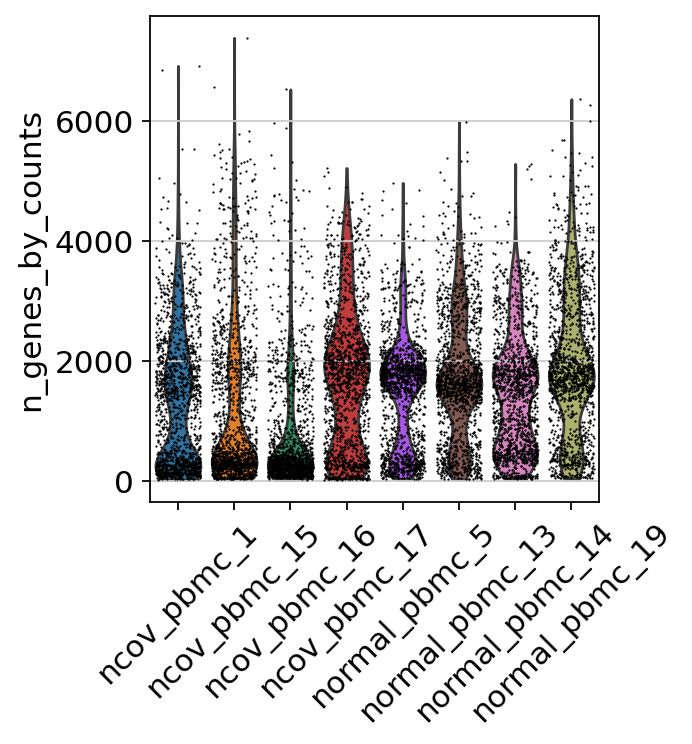

In [45]:
sc.pl.violin(adata,'n_genes_by_counts', jitter=0.4, groupby='sample', rotation=45)

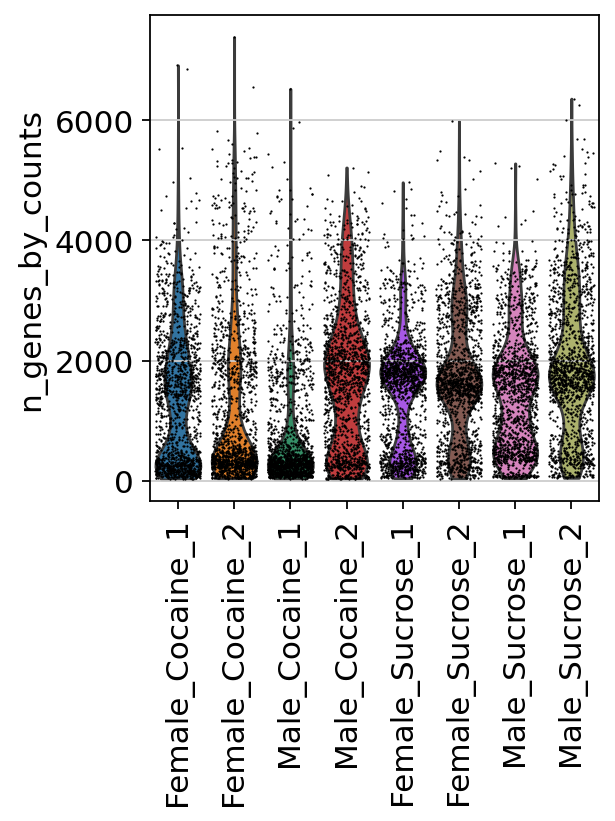

In [46]:
# Create a mapping dictionary from old names to your Drosophila project names
sample_rename_dict = {
    'ncov_pbmc_1': 'Female_Cocaine_1',
    'ncov_pbmc_15': 'Female_Cocaine_2',
    'ncov_pbmc_16': 'Male_Cocaine_1',
    'ncov_pbmc_17': 'Male_Cocaine_2',
    'normal_pbmc_5': 'Female_Sucrose_1',
    'normal_pbmc_13': 'Female_Sucrose_2',
    'normal_pbmc_14': 'Male_Sucrose_1',
    'normal_pbmc_19': 'Male_Sucrose_2'
}

# Apply the mapping to the sample metadata column
adata.obs['sample'] = adata.obs['sample'].map(sample_rename_dict)

# Re-run your plot
sc.pl.violin(adata, 'n_genes_by_counts', jitter=0.4, groupby='sample', rotation=90)

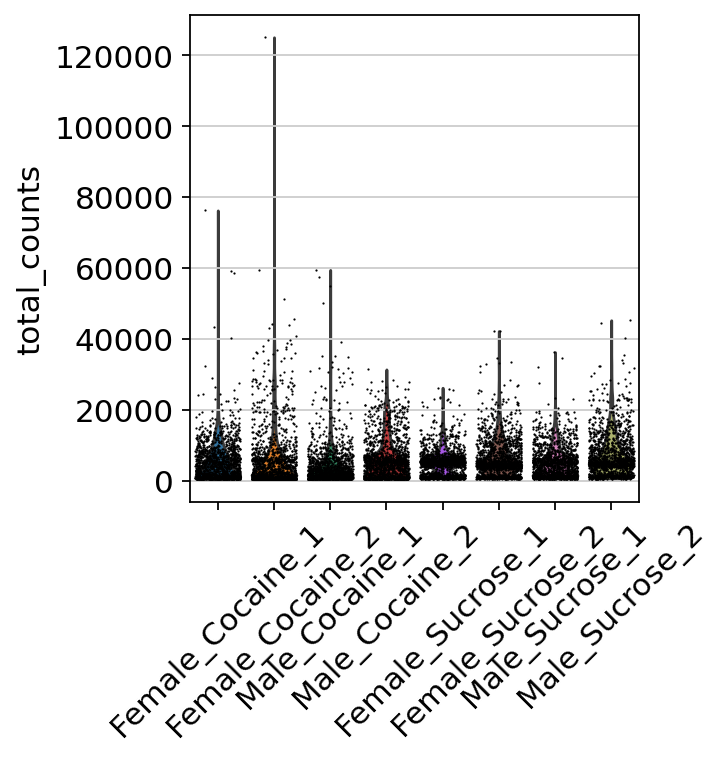

In [47]:
# total_counts Violin plot
sc.pl.violin(adata,'total_counts', jitter=0.4, groupby='sample', rotation=45)

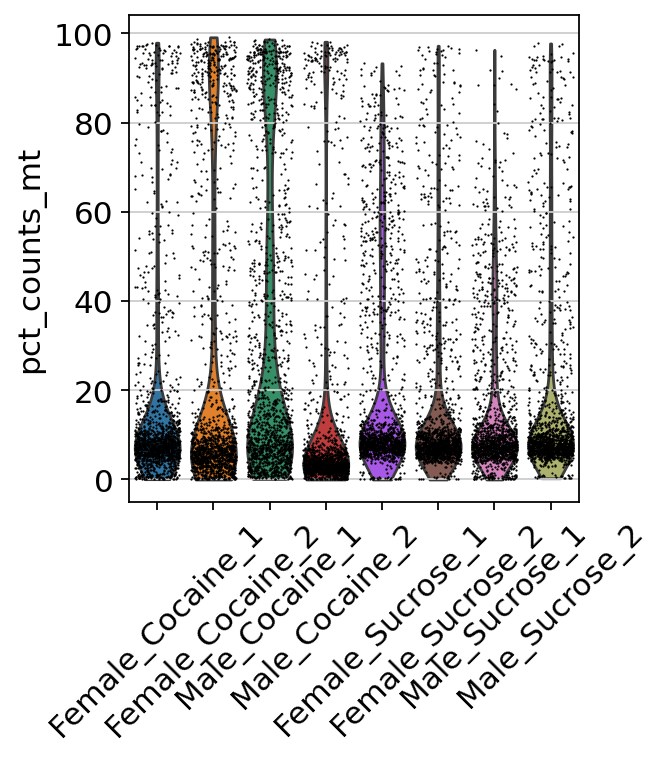

In [48]:
sc.pl.violin(adata,'pct_counts_mt', jitter=0.4, groupby='sample', rotation=45)

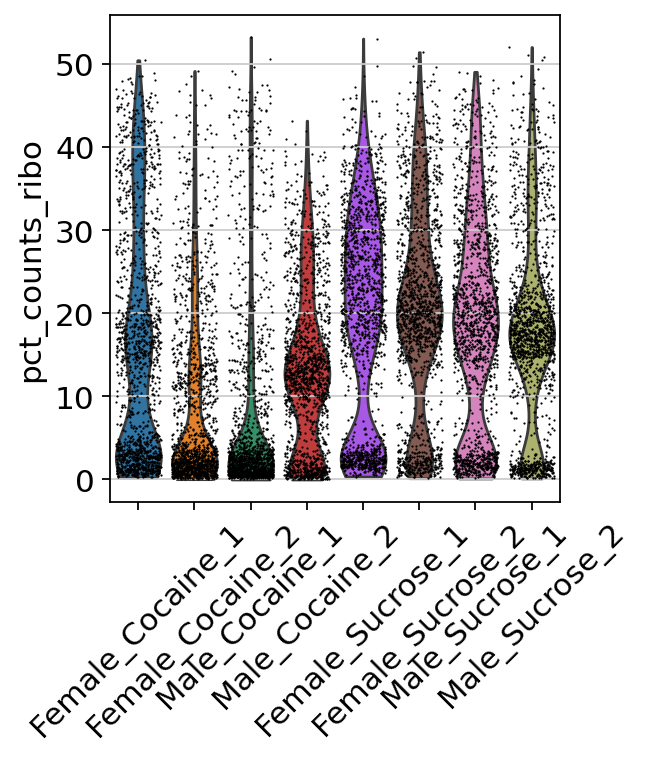

In [49]:
# pct_counts_ribo Violin plot
sc.pl.violin(adata,'pct_counts_ribo', jitter=0.4, groupby='sample', rotation=45)

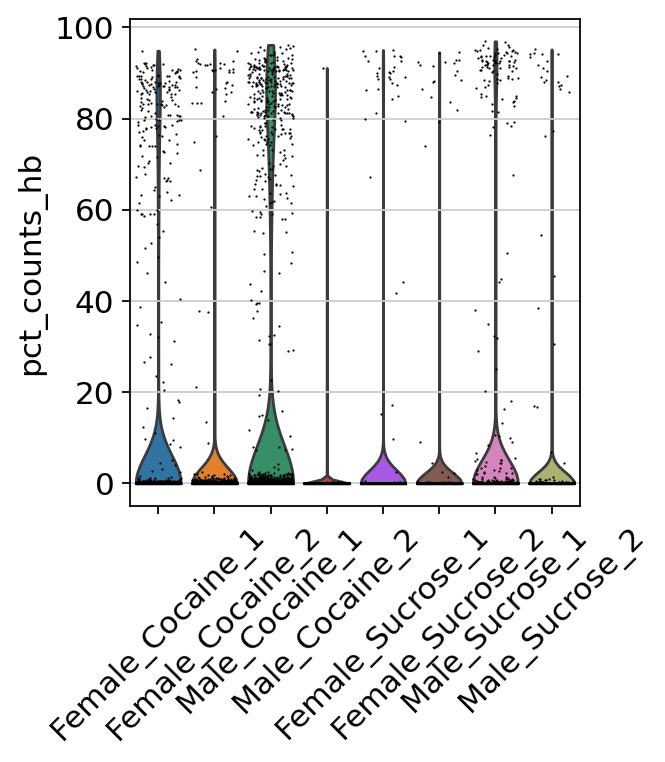

In [50]:
# pct_counts_hb Violin plot
sc.pl.violin(adata,'pct_counts_hb', jitter=0.4, groupby='sample', rotation=45)

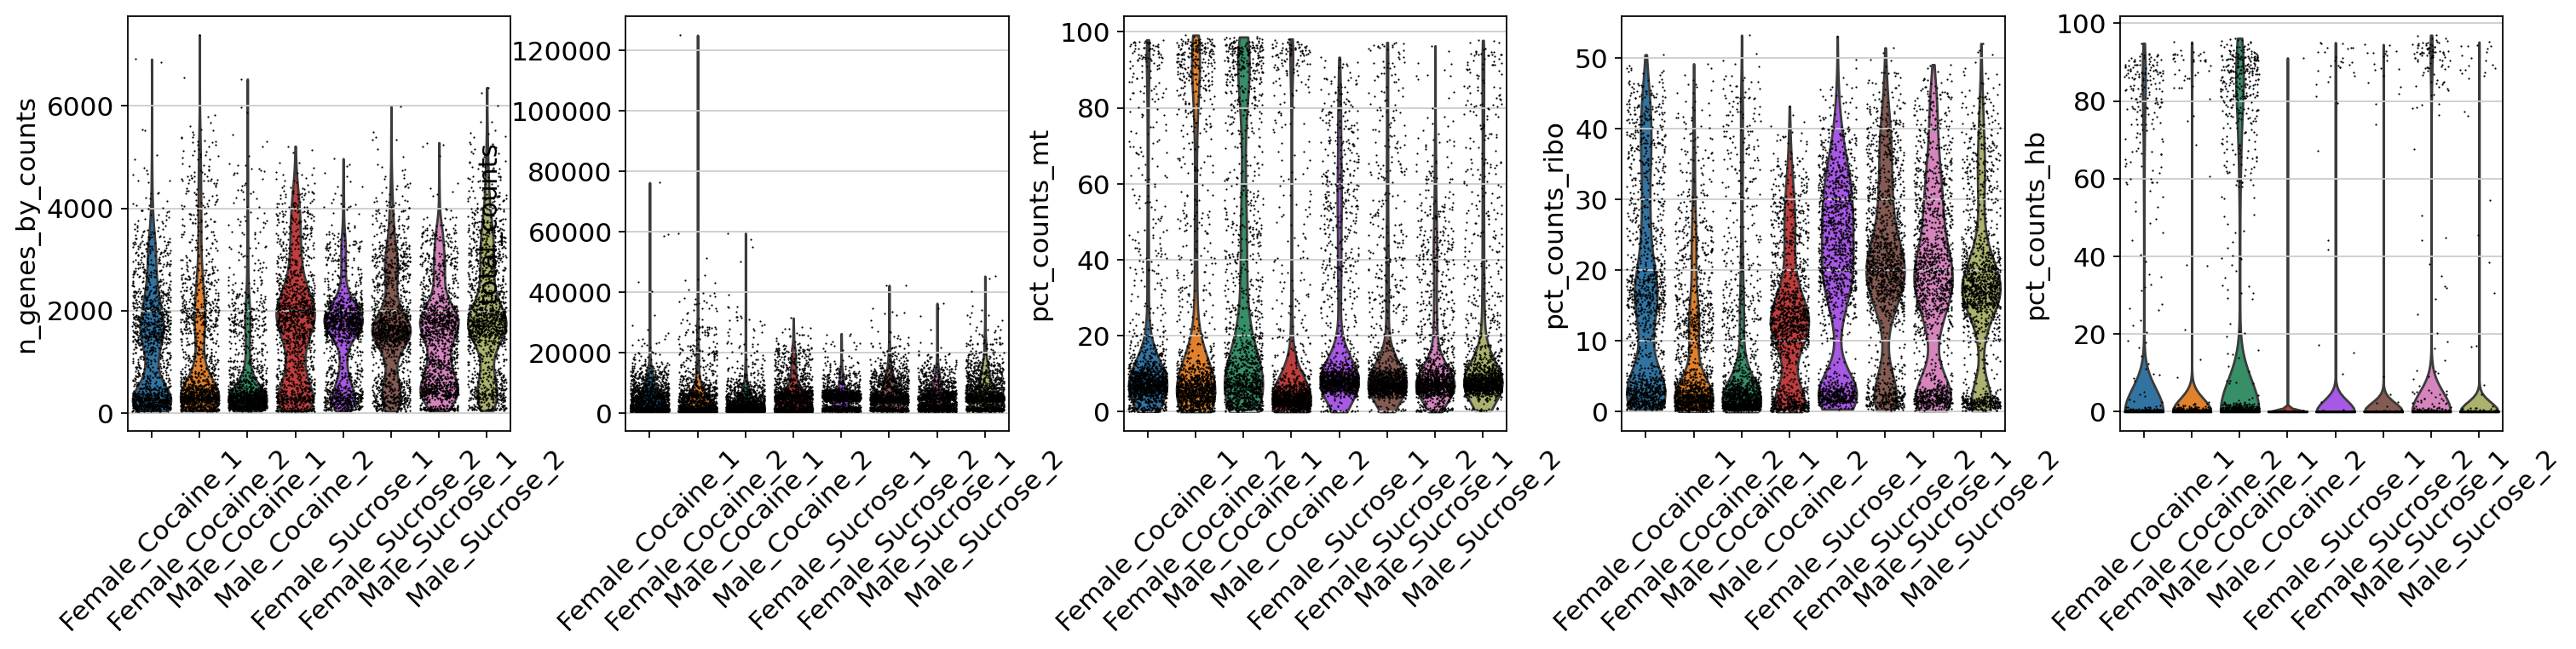

In [51]:
# Violin plot for all qc metrics
sc.pl.violin(adata,
 ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb'],
             jitter=0.4, groupby='sample', rotation=45)

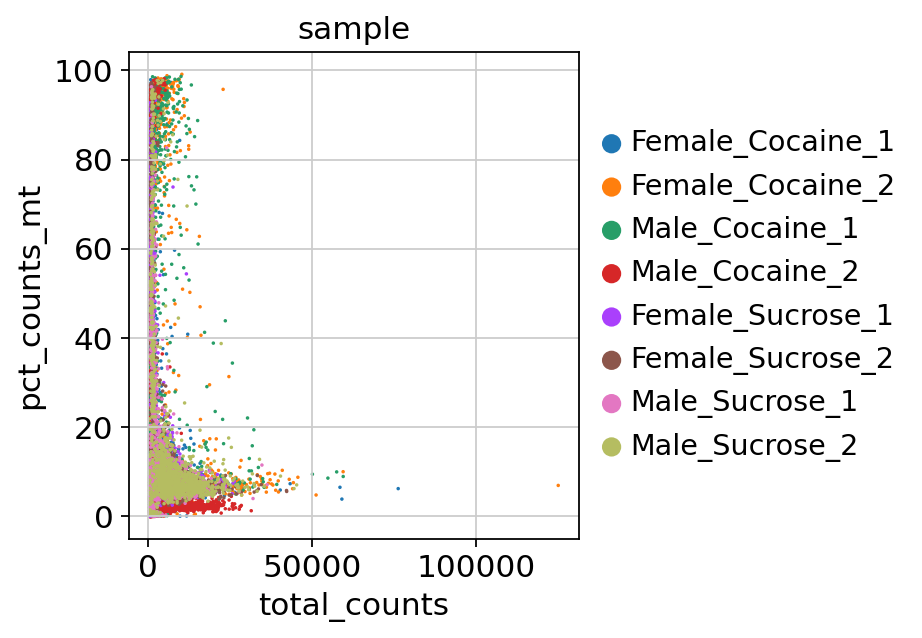

In [52]:
# qc-scatter for pct_counts_mt
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', color="sample")

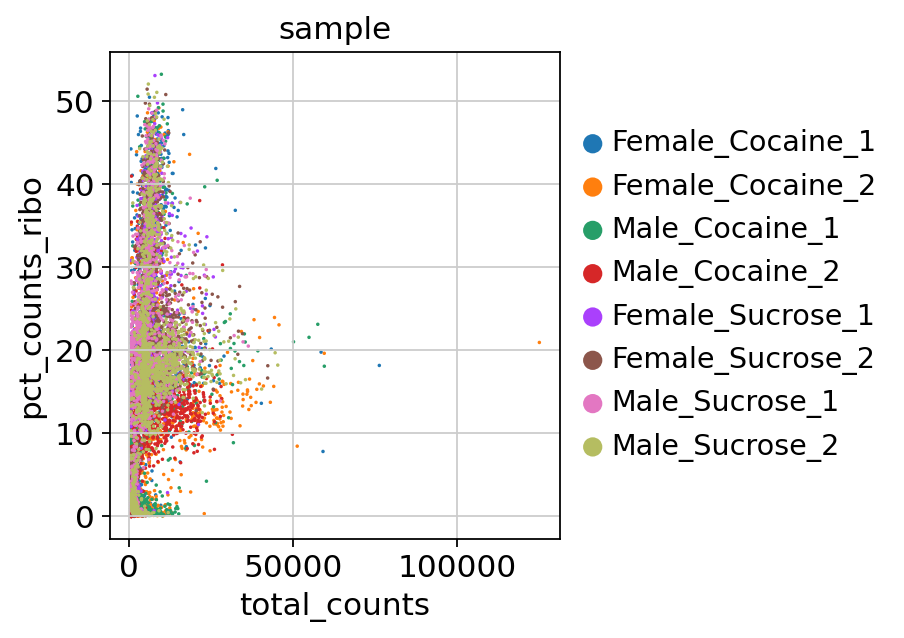

In [53]:
# qc-scatter for pct_counts_ribo
sc.pl.scatter(adata, x='total_counts', y='pct_counts_ribo', color="sample")

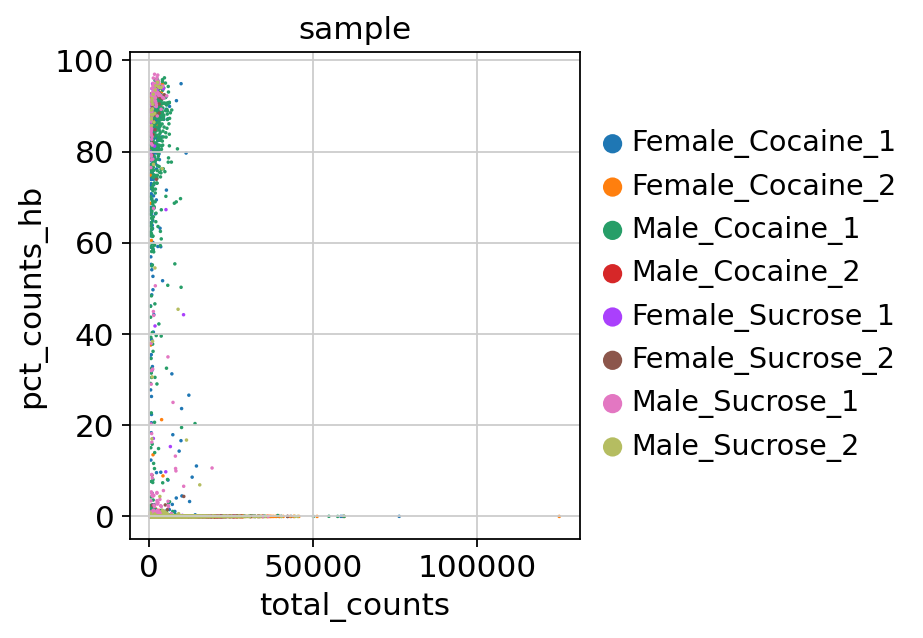

In [54]:
# qc-scatter for pct_counts_ribo
sc.pl.scatter(adata, x='total_counts', y='pct_counts_hb', color="sample")

In [55]:
# filtering criteria 1
sc.pp.filter_cells(adata, min_genes=200)

filtered out 1336 cells that have less than 200 genes expressed


In [56]:
# filtering criteria 2
sc.pp.filter_genes(adata, min_cells=3)

filtered out 14047 genes that are detected in less than 3 cells


In [57]:
adata

AnnData object with n_obs × n_vars = 10664 × 19491
    obs: 'type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'sample_colors'

normalizing counts per cell
    finished (0:00:05)


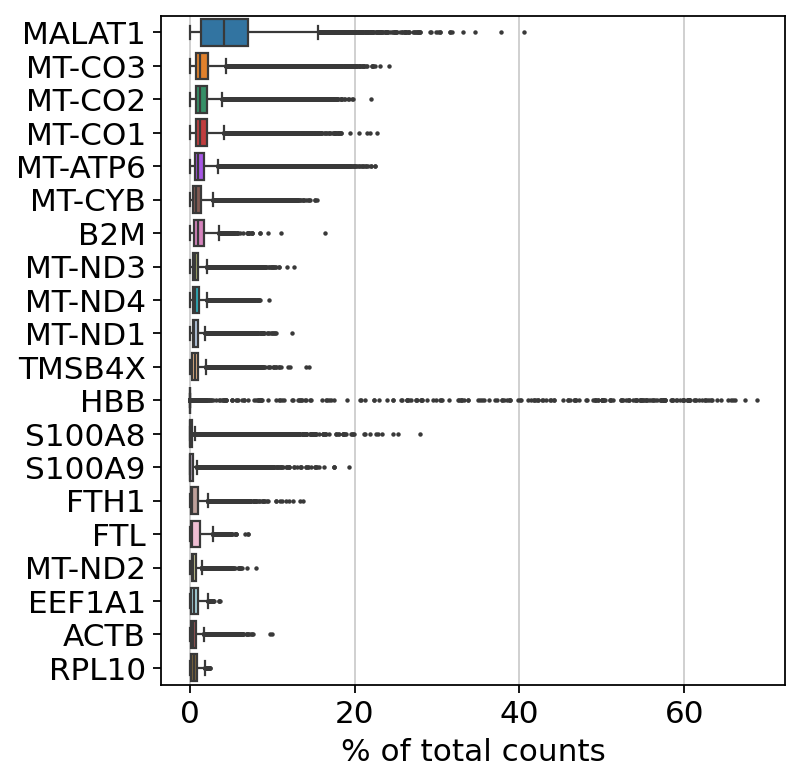

In [58]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [59]:
adata.obs

,type,sample,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb,n_genes
ncov_pbmc_1_AGGTAGGTCGTTGTTT-1,Untreated,Female_Cocaine_1,656,1396.0,26.0,1.862464,11.0,0.787966,1.0,0.071633,656
ncov_pbmc_1_TAGAGTCGTCCTCCAT-1,Untreated,Female_Cocaine_1,779,1613.0,186.0,11.531308,96.0,5.951643,0.0,0.000000,779
ncov_pbmc_1_CCCTGATAGCGAACTG-1,Untreated,Female_Cocaine_1,2036,9482.0,761.0,8.025733,4157.0,43.840962,3.0,0.031639,2036
ncov_pbmc_1_TCATCATTCCACGTAA-1,Untreated,Female_Cocaine_1,875,4357.0,2960.0,67.936654,99.0,2.272206,2.0,0.045903,875
ncov_pbmc_1_ATTTACCCAAGCCTGC-1,Untreated,Female_Cocaine_1,3290,12466.0,686.0,5.502968,2281.0,18.297770,1.0,0.008022,3290
...,...,...,...,...,...,...,...,...,...,...,...
normal_pbmc_5_GTACAGTAGTAGCATA-5,Untreated,Female_Sucrose_1,843,1823.0,468.0,25.671969,111.0,6.088865,0.0,0.000000,843
normal_pbmc_5_TCGAACATCGTGGACC-5,Untreated,Female_Sucrose_1,2119,7621.0,577.0,7.571185,2468.0,32.384202,0.0,0.000000,2119
normal_pbmc_5_CATTGCCGTGAATAAC-5,Untreated,Female_Sucrose_1,1867,4821.0,470.0,9.749015,1091.0,22.630160,0.0,0.000000,1867
normal_pbmc_5_GTTATGGCATCGTGGC-5,Untreated,Female_Sucrose_1,251,665.0,370.0,55.639098,19.0,2.857143,0.0,0.000000,251


In [60]:
adata = adata[adata.obs['pct_counts_mt'] < 20, :]
adata

View of AnnData object with n_obs × n_vars = 8648 × 19491
    obs: 'type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'sample_colors'

In [61]:
adata = adata[adata.obs['pct_counts_ribo'] >5, :]
adata

View of AnnData object with n_obs × n_vars = 7431 × 19491
    obs: 'type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'sample_colors'

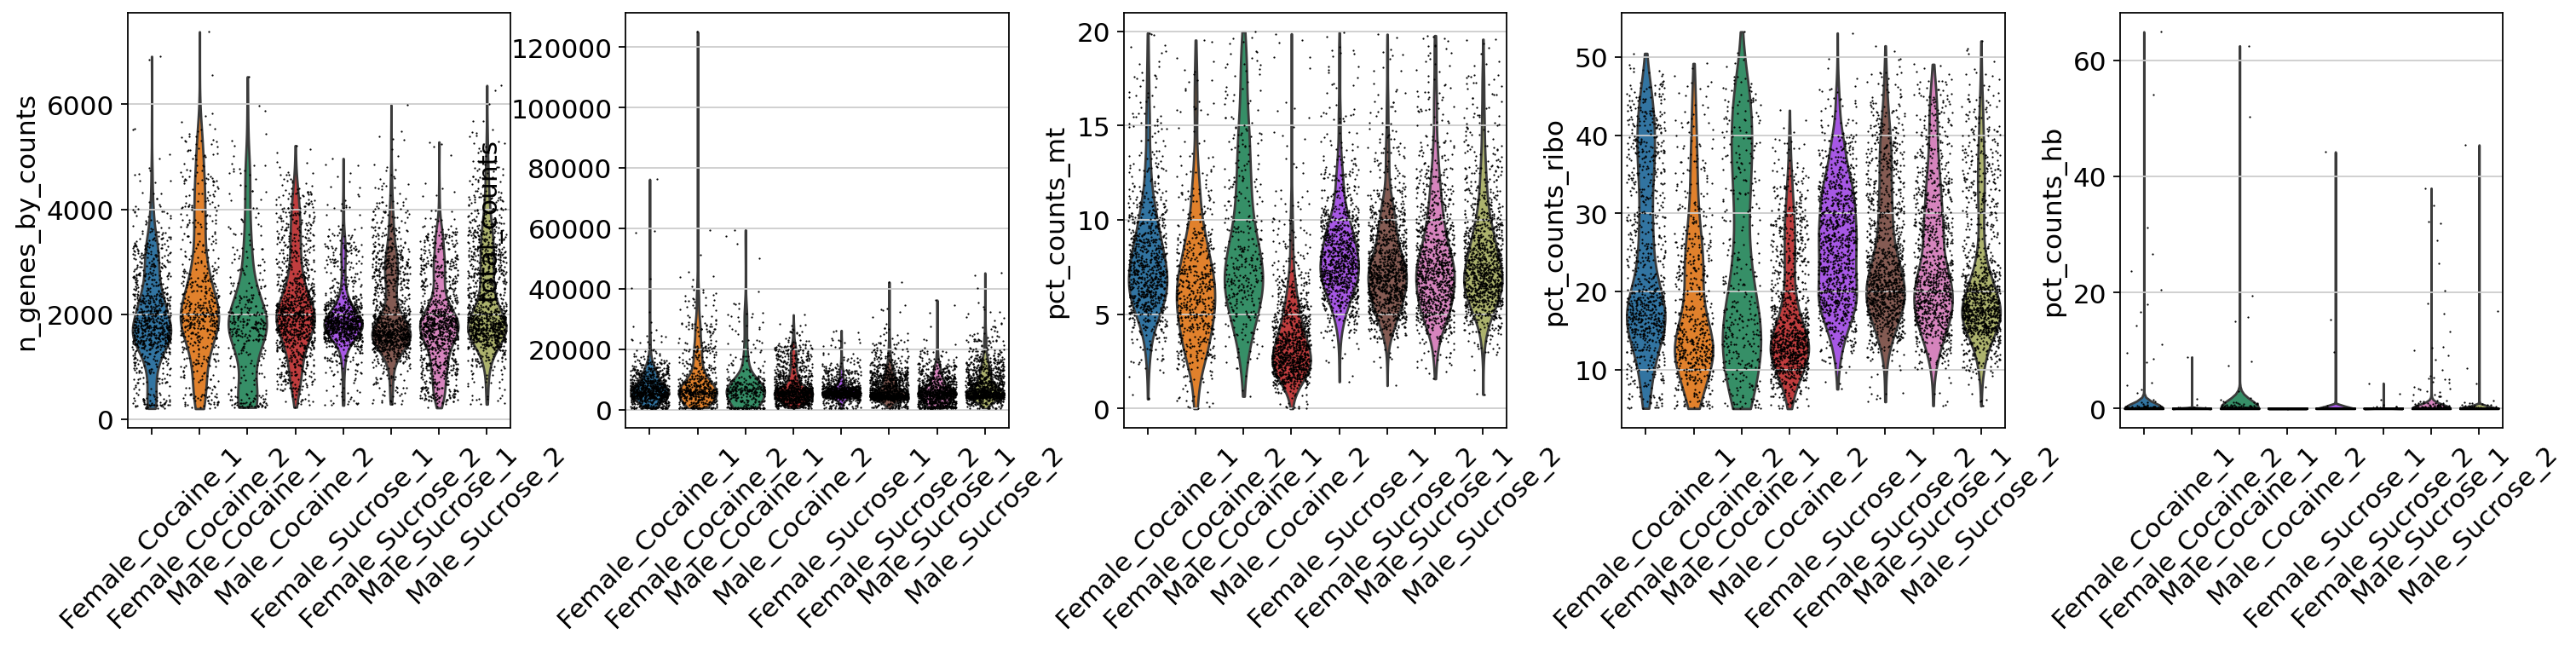

In [62]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt','pct_counts_ribo', 'pct_counts_hb'], jitter=0.4, groupby = 'sample', rotation = 45)

In [63]:
# filter-genes
malat1 = adata.var_names.str.startswith('MALAT1')
# we need to redefine the mito_genes since they were first
# calculated on the full object before removing low expressed genes.
mito_genes = adata.var_names.str.startswith('MT-')
hb_genes = adata.var_names.str.contains('^HB[^(P|E|S)]')

remove = np.add(mito_genes, malat1)
remove = np.add(remove, hb_genes)
keep = np.invert(remove)

adata = adata[:,keep]

In [64]:
adata

View of AnnData object with n_obs × n_vars = 7431 × 19468
    obs: 'type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'sample_colors'

In [65]:
%%capture
!uv pip install scrublet

In [66]:
import scrublet as scr

adata.obs['doublet_score'] = 0.0
adata.obs['predicted_doublet'] = False

for sample_id in adata.obs['sample'].unique():
    print(f"Processing {sample_id}...")
    b_idx = adata.obs['sample'] == sample_id

    # Use raw counts from adata.X
    counts_matrix = adata[b_idx].X

    scrub = scr.Scrublet(counts_matrix)
    doublet_scores, predicted_doublets = scrub.scrub_doublets(verbose=False)

    adata.obs.loc[b_idx, 'doublet_score'] = doublet_scores
    adata.obs.loc[b_idx, 'predicted_doublet'] = predicted_doublets

Processing Female_Cocaine_1...
Processing Female_Cocaine_2...
Processing Male_Cocaine_1...
Processing Male_Cocaine_2...
Processing Female_Sucrose_2...
Processing Male_Sucrose_1...
Processing Male_Sucrose_2...
Processing Female_Sucrose_1...


In [67]:
adata.obs

,type,sample,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb,n_genes,doublet_score,predicted_doublet
ncov_pbmc_1_TAGAGTCGTCCTCCAT-1,Untreated,Female_Cocaine_1,779,1613.0,186.0,11.531308,96.0,5.951643,0.0,0.000000,779,0.105960,False
ncov_pbmc_1_CCCTGATAGCGAACTG-1,Untreated,Female_Cocaine_1,2036,9482.0,761.0,8.025733,4157.0,43.840962,3.0,0.031639,2036,0.059382,False
ncov_pbmc_1_ATTTACCCAAGCCTGC-1,Untreated,Female_Cocaine_1,3290,12466.0,686.0,5.502968,2281.0,18.297770,1.0,0.008022,3290,0.089286,False
ncov_pbmc_1_GTTGTCCTCTAGAACC-1,Untreated,Female_Cocaine_1,1606,5541.0,707.0,12.759430,1664.0,30.030680,3.0,0.054142,1606,0.105960,False
ncov_pbmc_1_AATAGAGGTGTGAGCA-1,Untreated,Female_Cocaine_1,1285,4736.0,607.0,12.816723,1689.0,35.663007,5.0,0.105574,1285,0.059382,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
normal_pbmc_5_TTTGATCAGGCCTTCG-5,Untreated,Female_Sucrose_1,2207,8247.0,507.0,6.147690,2745.0,33.284831,0.0,0.000000,2207,0.114754,False
normal_pbmc_5_CGGGTGTGTTGTGTAC-5,Untreated,Female_Sucrose_1,1428,4663.0,585.0,12.545572,1583.0,33.948102,0.0,0.000000,1428,0.041825,False
normal_pbmc_5_TCGAACATCGTGGACC-5,Untreated,Female_Sucrose_1,2119,7621.0,577.0,7.571185,2468.0,32.384202,0.0,0.000000,2119,0.083110,False
normal_pbmc_5_CATTGCCGTGAATAAC-5,Untreated,Female_Sucrose_1,1867,4821.0,470.0,9.749015,1091.0,22.630160,0.0,0.000000,1867,0.125000,False


In [68]:
# check doublets
adata.obs['predicted_doublet'].value_counts()

,count
predicted_doublet,
False,7229
True,202


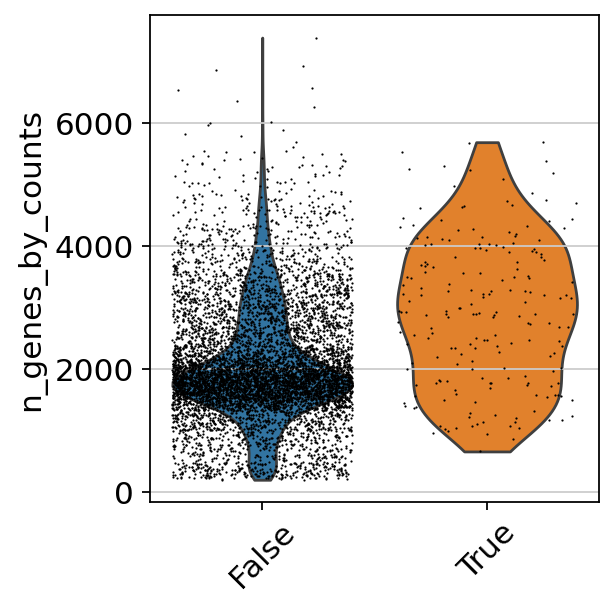

In [70]:
# plot-doublet
# add in column with singlet/doublet instead of True/Fals
adata.obs['doublet_info'] = adata.obs["predicted_doublet"].astype(str)
sc.pl.violin(adata, 'n_genes_by_counts', jitter=0.4, groupby = 'doublet_info', rotation=45)

In [71]:
# 1. Normalize
sc.pp.normalize_total(adata, target_sum=1e4)

# 2. Log transform
sc.pp.log1p(adata)

# 3. HVGs
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

# 4. Subset
adata = adata[:, adata.var.highly_variable].copy()

# 5. Regress
sc.pp.regress_out(
    adata,
    ['total_counts', 'pct_counts_mt']
)

# 6. Scale
sc.pp.scale(adata, max_value=10)

# 7. PCA
sc.tl.pca(adata, svd_solver='arpack', random_state=573)

# 8. Neighbors
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40, random_state=159)

# 9. UMAP
sc.tl.umap(adata, random_state=331)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:00:03)
computing PCA
    with n_comps=50
    finished (0:00:11)
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:41)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:15)


In [72]:
adata.obs

,type,sample,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb,n_genes,doublet_score,predicted_doublet,doublet_info
ncov_pbmc_1_TAGAGTCGTCCTCCAT-1,Untreated,Female_Cocaine_1,779,1613.0,186.0,11.531308,96.0,5.951643,0.0,0.000000,779,0.105960,False,False
ncov_pbmc_1_CCCTGATAGCGAACTG-1,Untreated,Female_Cocaine_1,2036,9482.0,761.0,8.025733,4157.0,43.840962,3.0,0.031639,2036,0.059382,False,False
ncov_pbmc_1_ATTTACCCAAGCCTGC-1,Untreated,Female_Cocaine_1,3290,12466.0,686.0,5.502968,2281.0,18.297770,1.0,0.008022,3290,0.089286,False,False
ncov_pbmc_1_GTTGTCCTCTAGAACC-1,Untreated,Female_Cocaine_1,1606,5541.0,707.0,12.759430,1664.0,30.030680,3.0,0.054142,1606,0.105960,False,False
ncov_pbmc_1_AATAGAGGTGTGAGCA-1,Untreated,Female_Cocaine_1,1285,4736.0,607.0,12.816723,1689.0,35.663007,5.0,0.105574,1285,0.059382,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
normal_pbmc_5_TTTGATCAGGCCTTCG-5,Untreated,Female_Sucrose_1,2207,8247.0,507.0,6.147690,2745.0,33.284831,0.0,0.000000,2207,0.114754,False,False
normal_pbmc_5_CGGGTGTGTTGTGTAC-5,Untreated,Female_Sucrose_1,1428,4663.0,585.0,12.545572,1583.0,33.948102,0.0,0.000000,1428,0.041825,False,False
normal_pbmc_5_TCGAACATCGTGGACC-5,Untreated,Female_Sucrose_1,2119,7621.0,577.0,7.571185,2468.0,32.384202,0.0,0.000000,2119,0.083110,False,False
normal_pbmc_5_CATTGCCGTGAATAAC-5,Untreated,Female_Sucrose_1,1867,4821.0,470.0,9.749015,1091.0,22.630160,0.0,0.000000,1867,0.125000,False,False


In [74]:
adata.obs['predicted_doublet'].value_counts()

,count
predicted_doublet,
False,7229
True,202


In [75]:
# doublet-filt
# also revert back to the raw counts as the main matrix in adata
adata = adata[adata.obs['doublet_info'] == 'False',:]

In [77]:
import os

output_dir = 'data/filtered'
if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)

adata.write_h5ad(os.path.join(output_dir, 'covid_qc_filtered.h5ad'))

In [78]:
import os

# 1. Remove the old COVID file if it exists
old_file = 'data/filtered/covid_qc_filtered.h5ad'
if os.path.exists(old_file):
    os.remove(old_file)
    print(f"Removed old file: {old_file}")

# 2. Create directory for filtered output if it doesn't exist
os.makedirs('data/filtered', exist_ok=True)

# 3. Save with your specified filename
new_file = 'data/filtered/drosophila_file.h5ad'
adata.write_h5ad(new_file)

print(f"Successfully saved filtered data to: {new_file}")

Removed old file: data/filtered/covid_qc_filtered.h5ad
Successfully saved filtered data to: data/filtered/drosophila_file.h5ad
